In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

PROJECT_DIR = Path(
    "/workspaces/DBA-ai-trust-score-framework-Interim"
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
REPORTS = PROJECT_DIR / "outputs"/"figures"

best_model = joblib.load(
    OUTPUT_DIR / "best_model.pkl"
)

print("Model loaded:", type(best_model).__name__)

Model loaded: LGBMClassifier


In [2]:
DATA = pd.read_csv(
    PROCESSED_DIR / "dms_features.csv"
)

print(DATA.shape)

(1400, 18)


In [3]:
from sklearn.preprocessing import LabelEncoder

TARGET = "label"

encoder = LabelEncoder()

DATA["target"] = encoder.fit_transform(
    DATA[TARGET]
)

MODEL_FEATURES = list(
    best_model.feature_names_in_
)

X = DATA[MODEL_FEATURES]
y = DATA["target"]

print("Features:", len(MODEL_FEATURES))
print(MODEL_FEATURES)

Features: 14
[np.str_('brightness'), np.str_('contrast'), np.str_('blur_score'), np.str_('entropy'), np.str_('edge_density'), np.str_('edge_strength'), np.str_('dynamic_range'), np.str_('width'), np.str_('height'), np.str_('aspect_ratio'), np.str_('image_area'), np.str_('size_mb'), np.str_('size_per_pixel'), np.str_('is_square')]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test samples:", len(X_test))

Test samples: 280


In [5]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("Predictions:", len(y_pred))
print("Probabilities:", y_prob.shape)

Predictions: 280
Probabilities: (280, 7)


### KPI 1 — PERFORMANCE

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

performance_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),

    "Precision": precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    ),

    "Macro_F1": f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
}

performance_metrics

{'Accuracy': 0.9107142857142857,
 'Precision': 0.9108519544930694,
 'Recall': 0.9107142857142857,
 'Macro_F1': 0.910475573164307}

In [7]:
performance_score = performance_metrics["Macro_F1"]

print(
    f"Performance KPI: {performance_score:.4f}"
)

Performance KPI: 0.9105


Per Class Performance

In [8]:
class_report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    output_dict=True,
    zero_division=0
)

class_performance = pd.DataFrame(
    class_report
).T

class_performance

,precision,recall,f1-score,support
ClosedEye,0.750000,0.750000,0.750000,40.000000
DangerousDriving,0.952381,1.000000,0.975610,40.000000
Distracted,0.975610,1.000000,0.987654,40.000000
Drinking,0.972973,0.900000,0.935065,40.000000
OpenEye,0.750000,0.750000,0.750000,40.000000
SafeDriving,1.000000,1.000000,1.000000,40.000000
Yawn,0.975000,0.975000,0.975000,40.000000
accuracy,0.910714,0.910714,0.910714,0.910714
macro avg,0.910852,0.910714,0.910476,280.000000
weighted avg,0.910852,0.910714,0.910476,280.000000


In [9]:
class_performance.to_csv(
    OUTPUT_DIR / "class_performance.csv"
)

### KPI 2 — SAFETY

In [10]:
UNSAFE_CLASSES = [
    "DangerousDriving",
    "Distracted",
    "Drinking",
    "Yawn"
]

SAFE_CLASS = "SafeDriving"

actual_labels = encoder.inverse_transform(
    y_test
)

predicted_labels = encoder.inverse_transform(
    y_pred
)

safety_df = pd.DataFrame({

    "actual": actual_labels,

    "predicted": predicted_labels

})

safety_df.head()

,actual,predicted
0,SafeDriving,SafeDriving
1,DangerousDriving,DangerousDriving
2,DangerousDriving,DangerousDriving
3,Drinking,Drinking
4,Yawn,Yawn


In [11]:
critical_errors = (

    safety_df["actual"].isin(
        UNSAFE_CLASSES
    )

    &

    (safety_df["predicted"] == SAFE_CLASS)

)

critical_error_count = critical_errors.sum()

critical_error_rate = (
    critical_error_count
    /
    safety_df["actual"].isin(
        UNSAFE_CLASSES
    ).sum()
)

print(
    "Safety-critical errors:",
    critical_error_count
)

print(
    "Safety-critical error rate:",
    round(
        critical_error_rate,
        4
    )
)

Safety-critical errors: 0
Safety-critical error rate: 0.0


In [12]:
safety_score = 1 - critical_error_rate

In [13]:
safety_score = max(
    0,
    1 - critical_error_rate
)

print(
    f"Safety KPI: {safety_score:.4f}"
)

Safety KPI: 1.0000


### KPI 3 — ROBUSTNESS

In [14]:
def evaluate_f1(
    model,
    X_data,
    y_true
):

    predictions = model.predict(
        X_data
    )

    return f1_score(
        y_true,
        predictions,
        average="macro",
        zero_division=0
    )

In [19]:
baseline_f1 = evaluate_f1(
    best_model,
    X_test,
    y_test
)

print(
    "Baseline Macro-F1:",
    round(
        baseline_f1,
        4
    )
)

Baseline Macro-F1: 0.9105


Brightness degradation

In [15]:
X_brightness = X_test.copy()

X_brightness["brightness"] = (
    X_brightness["brightness"] * 0.60
)

brightness_f1 = evaluate_f1(
    best_model,
    X_brightness,
    y_test
)

print(
    "Brightness-degraded F1:",
    round(
        brightness_f1,
        4
    )
)

Brightness-degraded F1: 0.8457


Contrast degradation

In [16]:
X_contrast = X_test.copy()

X_contrast["contrast"] = (
    X_contrast["contrast"] * 0.60
)

contrast_f1 = evaluate_f1(
    best_model,
    X_contrast,
    y_test
)

print(
    "Contrast-degraded F1:",
    round(
        contrast_f1,
        4
    )
)

Contrast-degraded F1: 0.8091


Blur degradation

In [17]:
X_blur = X_test.copy()

X_blur["blur_score"] = (
    X_blur["blur_score"] * 0.40
)

X_blur["edge_density"] = (
    X_blur["edge_density"] * 0.70
)

blur_f1 = evaluate_f1(
    best_model,
    X_blur,
    y_test
)

print(
    "Blur-degraded F1:",
    round(
        blur_f1,
        4
    )
)

Blur-degraded F1: 0.8528


Robustness table

In [20]:
robustness_results = pd.DataFrame({

    "Condition": [
        "Original",
        "Reduced Brightness",
        "Reduced Contrast",
        "Blurred"
    ],

    "Macro_F1": [
        baseline_f1,
        brightness_f1,
        contrast_f1,
        blur_f1
    ]

})

robustness_results

,Condition,Macro_F1
0,Original,0.910476
1,Reduced Brightness,0.845748
2,Reduced Contrast,0.809085
3,Blurred,0.852755


In [21]:
degraded_scores = [
    brightness_f1,
    contrast_f1,
    blur_f1
]

robustness_score = (
    np.mean(degraded_scores)
    /
    baseline_f1
)

robustness_score = np.clip(
    robustness_score,
    0,
    1
)

print(
    f"Robustness KPI: {robustness_score:.4f}"
)

Robustness KPI: 0.9181


In [22]:
degraded_mean_f1 = np.mean(degraded_scores)

robustness_retention = (
    degraded_mean_f1 / baseline_f1
)

performance_degradation = (
    1 - robustness_retention
)

print(f"Baseline Macro-F1:        {baseline_f1:.4f}")
print(f"Mean degraded Macro-F1:   {degraded_mean_f1:.4f}")
print(f"Performance retention:    {robustness_retention:.4f}")
print(f"Performance degradation:  {performance_degradation*100 :.1f}%")

Baseline Macro-F1:        0.9105
Mean degraded Macro-F1:   0.8359
Performance retention:    0.9181
Performance degradation:  8.2%


### KPI 4 — Calibration

Multiclass Brier Score - This answers:

When the model says it is highly confident, can we trust that confidence? Lower the better

In [23]:
from sklearn.preprocessing import label_binarize

classes = np.arange(
    len(encoder.classes_)
)

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

brier_score = np.mean(
    np.sum(
        (
            y_prob
            -
            y_test_binary
        ) ** 2,
        axis=1
    )
)

print(
    f"Multiclass Brier Score: "
    f"{brier_score:.4f}"
)

Multiclass Brier Score: 0.1360


In [24]:
confidence = np.max(
    y_prob,
    axis=1
)

correct = (
    y_pred == y_test
)

n_bins = 10

bins = np.linspace(
    0,
    1,
    n_bins + 1
)

ece = 0.0

for i in range(n_bins):

    if i == n_bins - 1:

        mask = (
            (confidence >= bins[i])
            &
            (confidence <= bins[i + 1])
        )

    else:

        mask = (
            (confidence >= bins[i])
            &
            (confidence < bins[i + 1])
        )

    if mask.sum() == 0:
        continue

    bin_accuracy = correct[mask].mean()

    bin_confidence = confidence[mask].mean()

    bin_weight = mask.mean()

    ece += (
        bin_weight
        *
        abs(
            bin_accuracy
            -
            bin_confidence
        )
    )

print(
    f"Expected Calibration Error: "
    f"{ece:.4f}"
)

Expected Calibration Error: 0.0633


In [25]:
calibration_score = np.clip(
    1 - ece,
    0,
    1
)

print(
    f"Calibration KPI: "
    f"{calibration_score:.4f}"
)

Calibration KPI: 0.9367


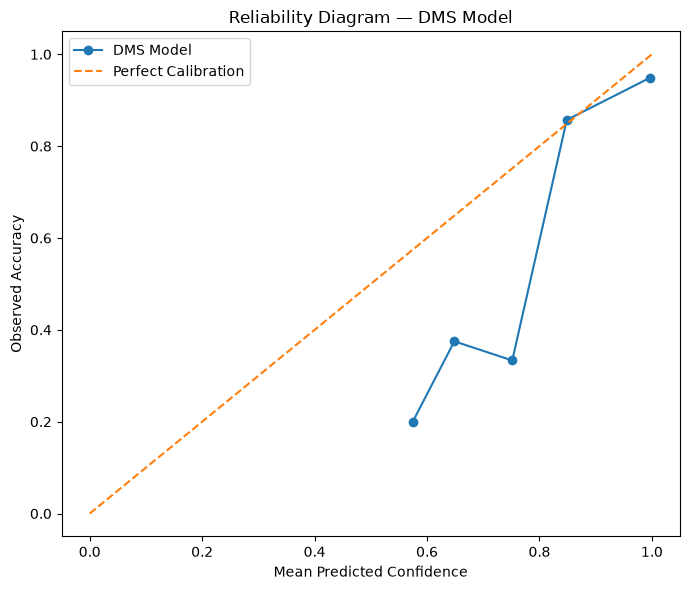

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

# Correctness of prediction
correct = (
    y_pred == y_test
).astype(int)

confidence = np.max(
    y_prob,
    axis=1
)

prob_true, prob_pred = calibration_curve(
    correct,
    confidence,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="DMS Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "Reliability Diagram — DMS Model"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORTS / "calibration_reliability.png",
    dpi=300
)

plt.show()

### KPI5 Explainability

In [27]:
if hasattr(
    best_model,
    "feature_importances_"
):

    feature_importance = pd.DataFrame({

        "Feature": X_test.columns,

        "Importance":
            best_model.feature_importances_

    }).sort_values(
        "Importance",
        ascending=False
    )

else:

    feature_importance = pd.DataFrame()

feature_importance

,Feature,Importance
0,brightness,4776
1,contrast,4566
3,entropy,4272
2,blur_score,4135
4,edge_density,3978
11,size_mb,3514
12,size_per_pixel,3471
6,dynamic_range,2915
9,aspect_ratio,884
5,edge_strength,835


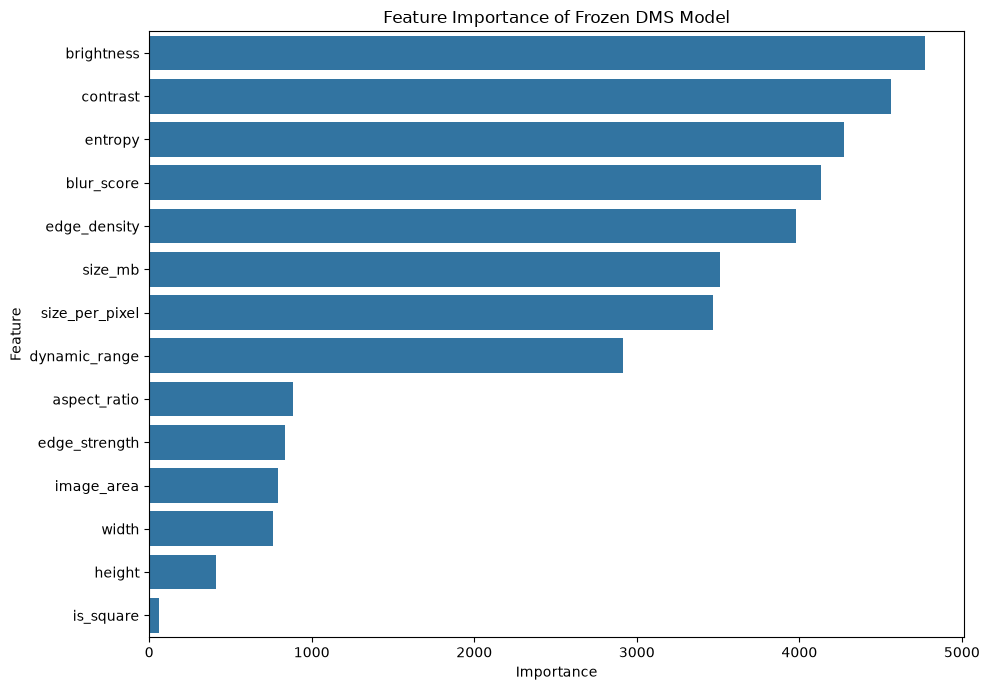

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance of Frozen DMS Model"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    REPORTS / "feature_importance.png",
    dpi=300
)

plt.show()

### KPI6 Fairness

In [29]:
fairness_result = {

    "Status": "Not Assessable",

    "Reason":
        "The selected DMS dataset does not contain "
        "sufficient demographic/protected subgroup "
        "attributes for fairness evaluation."

}

fairness_result

{'Status': 'Not Assessable',
 'Reason': 'The selected DMS dataset does not contain sufficient demographic/protected subgroup attributes for fairness evaluation.'}

### KPI7 Privacy

In [30]:
privacy_result = {

    "Status": "Not Assessable",

    "Reason":
        "The current dataset does not provide the "
        "required privacy attack, identity leakage, "
        "or PII exposure ground truth."

}

privacy_result

{'Status': 'Not Assessable',
 'Reason': 'The current dataset does not provide the required privacy attack, identity leakage, or PII exposure ground truth.'}

## AI Trust Score

In [31]:
WEIGHTS = {

    "Performance": 0.30,

    "Safety": 0.35,

    "Robustness": 0.20,

    "Calibration": 0.15

}

In [32]:
trust_score = (

    performance_score
    * WEIGHTS["Performance"]

    +

    safety_score
    * WEIGHTS["Safety"]

    +

    robustness_score
    * WEIGHTS["Robustness"]

    +

    calibration_score
    * WEIGHTS["Calibration"]

)

trust_score_100 = (
    trust_score * 100
)

print(
    f"AI Trust Score: "
    f"{trust_score_100:.2f} / 100"
)

AI Trust Score: 94.73 / 100


In [35]:
trust_components = pd.DataFrame({

    "Dimension": [
        "Performance",
        "Safety",
        "Robustness",
        "Calibration"
    ],

    "Score": [
        performance_score,
        safety_score,
        robustness_score,
        calibration_score
    ],

    "Weight": [
        WEIGHTS["Performance"],
        WEIGHTS["Safety"],
        WEIGHTS["Robustness"],
        WEIGHTS["Calibration"]
    ]

})

trust_components["Weighted Contribution"] = (
    trust_components["Score"]
    *
    trust_components["Weight"]
)

trust_components

,Dimension,Score,Weight,Weighted Contribution
0,Performance,0.910476,0.30,0.273143
1,Safety,1.000000,0.35,0.350000
2,Robustness,0.918050,0.20,0.183610
3,Calibration,0.936657,0.15,0.140499


In [37]:
robustness_results.to_csv(
    OUTPUT_DIR /
    "robustness_results.csv",
    index=False
)

trust_components.to_csv(
    OUTPUT_DIR /
    "ai_trust_score_components.csv",
    index=False
)

feature_importance.to_csv(
    OUTPUT_DIR /
    "explainability_feature_importance.csv",
    index=False
)

#print("✅ KPI results saved")
print("✅ Robustness results saved")
print("✅ Trust Score components saved")
print("✅ Explainability results saved")

✅ Robustness results saved
✅ Trust Score components saved
✅ Explainability results saved
